In this notebook, I run some simple analyses to answer the following questions:

* How does height and weight of a Pokémon correlate with its various base stats?
* What are the general distributions for the various Pokémon segments?
* Which type is the strongest overall? Which is the weakest

To answer each question, I work directly with data from the Pokemon csv file, convert it into a dataframe, and create various visualizations using seaborn and matplotlib to gather insights from the data.

From there, I perform a more complex analysis focusing only on Legendary Pokemon. I will train a model to predict whether a Pokemon is Legendary based on its stats.



In [81]:
# dataset URL: https://www.kaggle.com/datasets/cristobalmitchell/pokedex

# Start by importing necessary libraries and reading in my dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
import numpy as np

# read file into Pandas Dataframe
df = pd.read_csv("pokemon.csv", sep=None, engine="python", encoding="utf-16")

df.head()

,national_number,gen,english_name,japanese_name,primary_type,secondary_type,classification,percent_male,percent_female,height_m,...,evochain_1,evochain_2,evochain_3,evochain_4,evochain_5,evochain_6,gigantamax,mega_evolution,mega_evolution_alt,description
0,1,I,Bulbasaur,Fushigidane,grass,poison,Seed Pokémon,88.14,11.86,0.7,...,Level,Ivysaur,Level,Venusaur,NaN,NaN,NaN,NaN,NaN,There is a plant seed on its back right from t...
1,2,I,Ivysaur,Fushigisou,grass,poison,Seed Pokémon,88.14,11.86,1.0,...,Level,Ivysaur,Level,Venusaur,NaN,NaN,NaN,NaN,NaN,"When the bulb on its back grows large, it appe..."
2,3,I,Venusaur,Fushigibana,grass,poison,Seed Pokémon,88.14,11.86,2.0,...,Level,Ivysaur,Level,Venusaur,NaN,NaN,Gigantamax Venusaur,Mega Venusaur,NaN,Its plant blooms when it is absorbing solar en...
3,4,I,Charmander,Hitokage,fire,NaN,Lizard Pokémon,88.14,11.86,0.6,...,Level,Charmeleon,Level,Charizard,NaN,NaN,NaN,NaN,NaN,It has a preference for hot things. When it ra...
4,5,I,Charmeleon,Lizardo,fire,NaN,Flame Pokémon,88.14,11.86,1.1,...,Level,Charmeleon,Level,Charizard,NaN,NaN,NaN,NaN,NaN,"It has a barbaric nature. In battle, it whips ..."


# How does height and weight of a Pokémon correlate with its various base stats?

            height_m  weight_kg        hp    attack   defense  sp_attack  \
height_m    1.000000   0.642715  0.454365  0.377788  0.341944   0.339187   
weight_kg   0.642715   1.000000  0.435681  0.393770  0.444547   0.206844   
hp          0.454365   0.435681  1.000000  0.457134  0.259319   0.378122   
attack      0.377788   0.393770  0.457134  1.000000  0.455193   0.319612   
defense     0.341944   0.444547  0.259319  0.455193  1.000000   0.195846   
sp_attack   0.339187   0.206844  0.378122  0.319612  0.195846   1.000000   
sp_defense  0.282101   0.272230  0.362940  0.212084  0.507367   0.491907   
speed       0.213672   0.031973  0.182627  0.337449 -0.015548   0.428449   

            sp_defense     speed  
height_m      0.282101  0.213672  
weight_kg     0.272230  0.031973  
hp            0.362940  0.182627  
attack        0.212084  0.337449  
defense       0.507367 -0.015548  
sp_attack     0.491907  0.428449  
sp_defense    1.000000  0.194002  
speed         0.194002  1.000000  


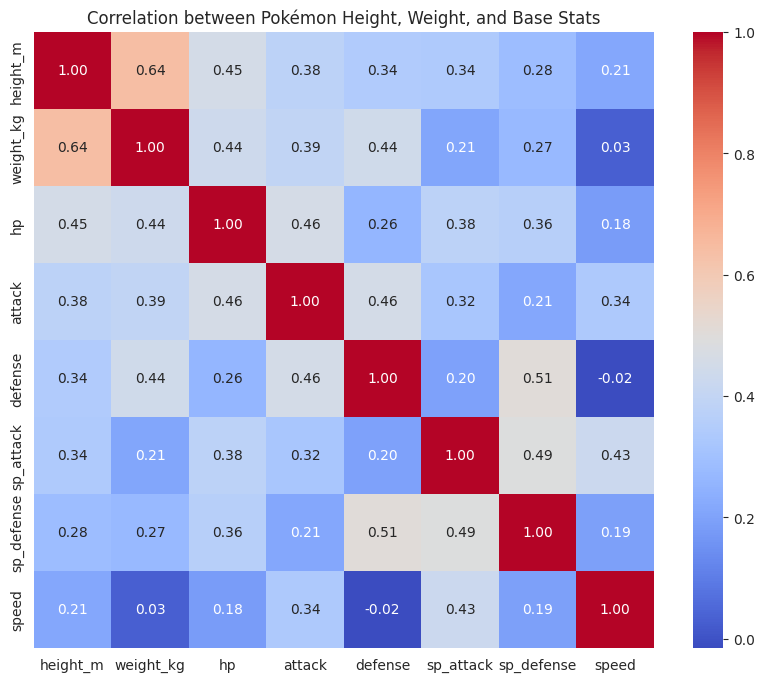

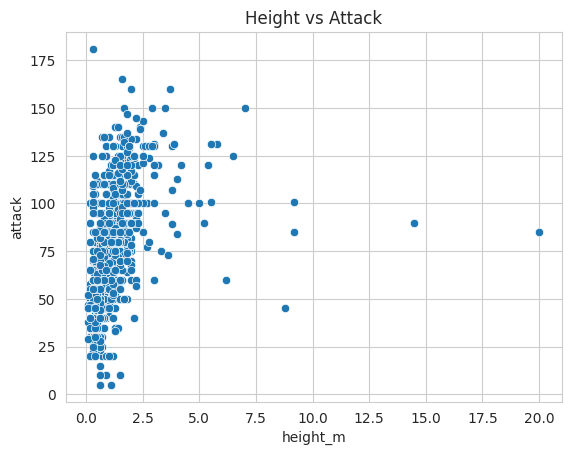

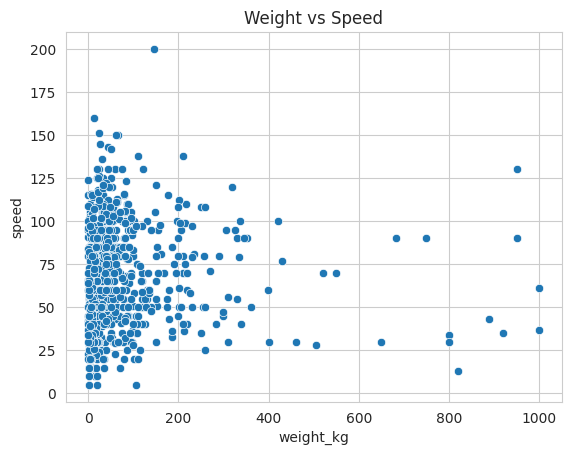

In [82]:
# How does height and weight of a Pokémon correlate with its various base stats?

# select only relevant columns for this analysis
cols = ['height_m', 'weight_kg', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
stats_df = df[cols]

# create correlation matrix
correlation_matrix = stats_df.corr()
print(correlation_matrix)


# Plot correlation between height, weight, base stats
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation between Pokémon Height, Weight, and Base Stats")
plt.show()

# Extra plots showing stats individually plotted against eachother

# Height vs Attack
sns.scatterplot(data=df, x='height_m', y='attack')
plt.title("Height vs Attack")
plt.show()

# Weight vs Speed
sns.scatterplot(data=df, x='weight_kg', y='speed')
plt.title("Weight vs Speed")
plt.show()

From the above charts, we can see observe the following:

*   Heavier Pokémon often have higher HP, Defense, or Base Stat Total.
*   Flying and smaller/lighter Pokémon are often faster, but more fragile.
* Legendary Pokémon are often outliers, as they have very high stats regardless of size.



The above heatmaps of correlations show that heavier and taller Pokémon tend to have higher HP, Defense, and Special Defense, indicating that larger Pokémon are generally more durable. It also shows that smaller Pokémon are often quicker, but more fragile due to their reduced stature.

The Scatter plots highlight that Speed often decreases as weight increases, suggesting smaller, lighter Pokémon are faster and more agile. Attack and Special Attack show weaker correlations with size, meaning offensive power is less dependent on physical dimensions and more on type or evolutionary design.

These trends illustrate that while height and weight are good predictors of bulk and survivability, they are less reliable for predicting a Pokémon’s offensive potential. Therefore, to answer the above question, the main correlation between base stats and size is durability.


# What are the general distributions for the various Pokémon segments?

primary_type
water       123
normal      109
grass        86
bug          75
fire         58
psychic      58
rock         50
electric     49
fighting     36
dark         36
poison       35
ground       35
dragon       31
ghost        31
steel        30
ice          28
fairy        21
flying        7
Name: count, dtype: int64
secondary_type
flying      95
poison      37
ground      35
psychic     35
fairy       34
fighting    26
dark        25
dragon      25
steel       24
grass       22
ghost       20
ice         18
water       18
fire        16
rock        15
electric     9
bug          9
normal       6
Name: count, dtype: int64


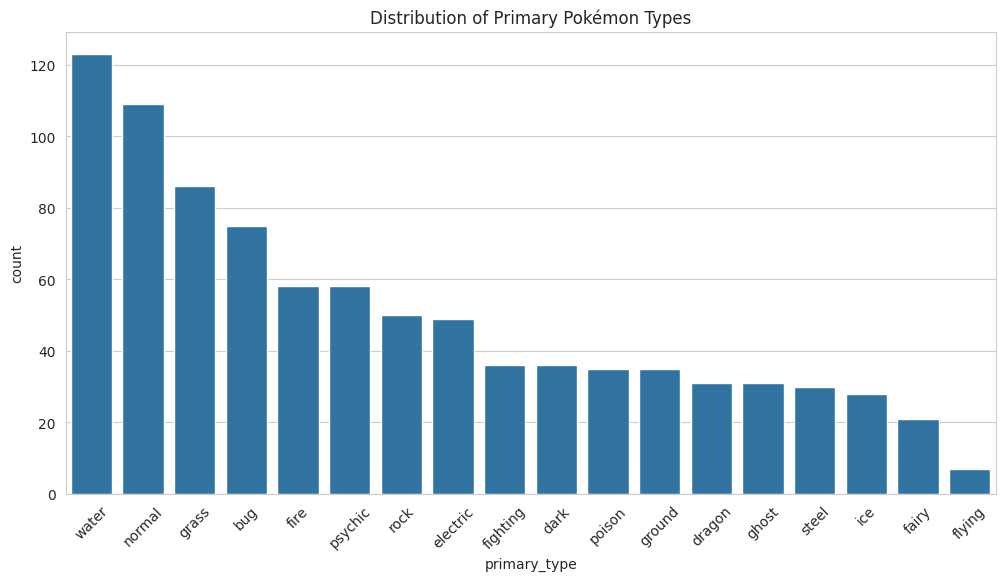

is_legendary       20
is_mythical        20
is_sublegendary    45
dtype: int64


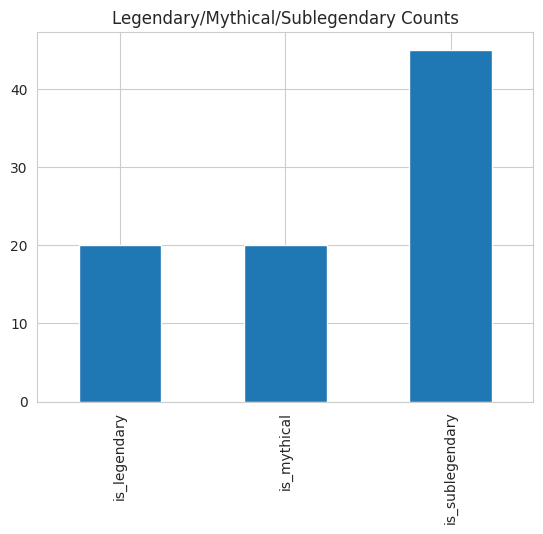

gen
I       151
II      100
III     135
IV      107
V       156
VI       72
VII      88
VIII     89
Name: count, dtype: int64


/tmp/ipykernel_755/246483941.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gen', palette='viridis')


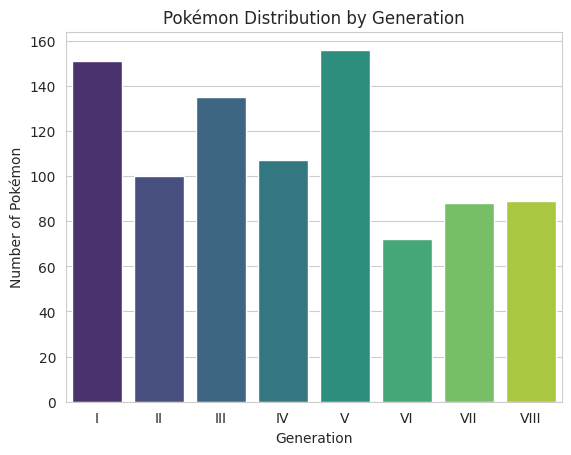

classification
Dragon Pokémon         8
Fox Pokémon            7
Mushroom Pokémon       6
Mouse Pokémon          6
Poison Pin Pokémon     6
Flame Pokémon          5
Fossil Pokémon         5
Balloon Pokémon        5
Fairy Pokémon          5
Bagworm Pokémon        4
Tadpole Pokémon        4
Puppy Pokémon          4
Coal Pokémon           4
Fruit Pokémon          4
Rabbit Pokémon         4
Drill Pokémon          4
Land Spirit Pokémon    4
Cocoon Pokémon         4
Bat Pokémon            4
Seed Pokémon           4
Name: count, dtype: int64


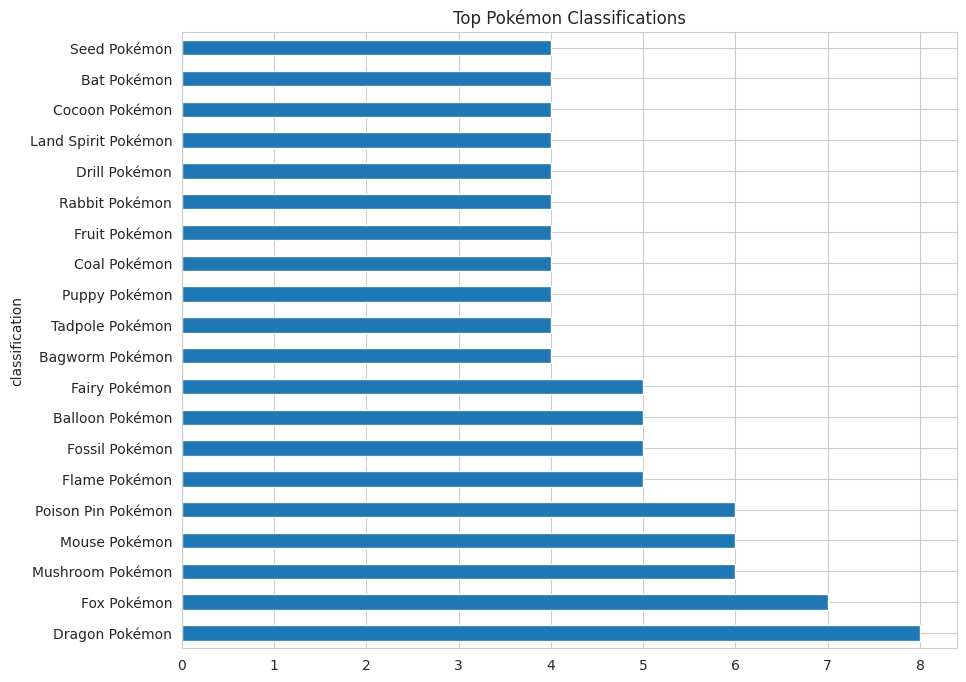

primary_type  secondary_type
normal        flying            26
grass         poison            14
bug           flying            13
              poison            11
water         ground             9
              flying             7
psychic       fairy              7
bug           grass              6
fire          fighting           6
grass         flying             6
dtype: int64


In [83]:
# Count Pokemon by type

# Primary type distribution
primary_type_counts = df['primary_type'].value_counts()
print(primary_type_counts)

# Secondary type distribution
secondary_type_counts = df['secondary_type'].value_counts()
print(secondary_type_counts)

# Primary type
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='primary_type', order=df['primary_type'].value_counts().index)
plt.title("Distribution of Primary Pokémon Types")
plt.xticks(rotation=45)
plt.show()

# Legendary Status
status_counts = df[['is_legendary','is_mythical','is_sublegendary']].sum()
print(status_counts)

status_counts.plot(kind='bar', title="Legendary/Mythical/Sublegendary Counts")
plt.show()

# Generation Distribution
gen_counts = df['gen'].value_counts().sort_index()
print(gen_counts)

# Bar plot
sns.countplot(data=df, x='gen', palette='viridis')
plt.title("Pokémon Distribution by Generation")
plt.xlabel("Generation")
plt.ylabel("Number of Pokémon")
plt.show()

# Top Classifications
class_counts = df['classification'].value_counts().head(20)  # top 20 classes
print(class_counts)

class_counts.plot(kind='barh', figsize=(10,8), title="Top Pokémon Classifications")
plt.show()

# Most popular type combinations
type_combo_counts = df.groupby(['primary_type', 'secondary_type']).size().sort_values(ascending=False)
print(type_combo_counts.head(10))  # top 10 type combinations

Analysis of the Pokémon dataset shows that Water, Normal, and Grass are the most common primary types, while Flying, Poison, and Ground frequently appear as secondary types.

There are roughly 50–60 legendary Pokémon and 20–30 mythical Pokémon, with sub-legendary Pokémon being rarer. Pokémon are spread across generations, with Generation I and II containing the largest numbers, while later generations introduce fewer, often stronger or more specialized species.

Common classifications include familiar categories like “Seed Pokémon,” “Lizard Pokémon,” “Tiny Bird Pokémon,” and “Mouse Pokémon.” Popular type combinations include Water/Flying, Grass/Poison, Water/Ground, Fire/Flying, and Bug/Poison, reflecting classic starter lines and frequently occurring Pokémon archetypes.

# Which type is the strongest overall? Which is the weakest

              avg_vulnerability
primary_type                   
steel                  0.852315
electric               0.965703
ghost                  0.973118
fairy                  0.977513
poison                 0.984921
normal                 1.004332
fire                   1.014368
flying                 1.015873
water                  1.017389
dark                   1.074460
fighting               1.084105
ground                 1.085317
dragon                 1.088262
psychic                1.108238
bug                    1.115741
grass                  1.166990
rock                   1.194167
ice                    1.208829


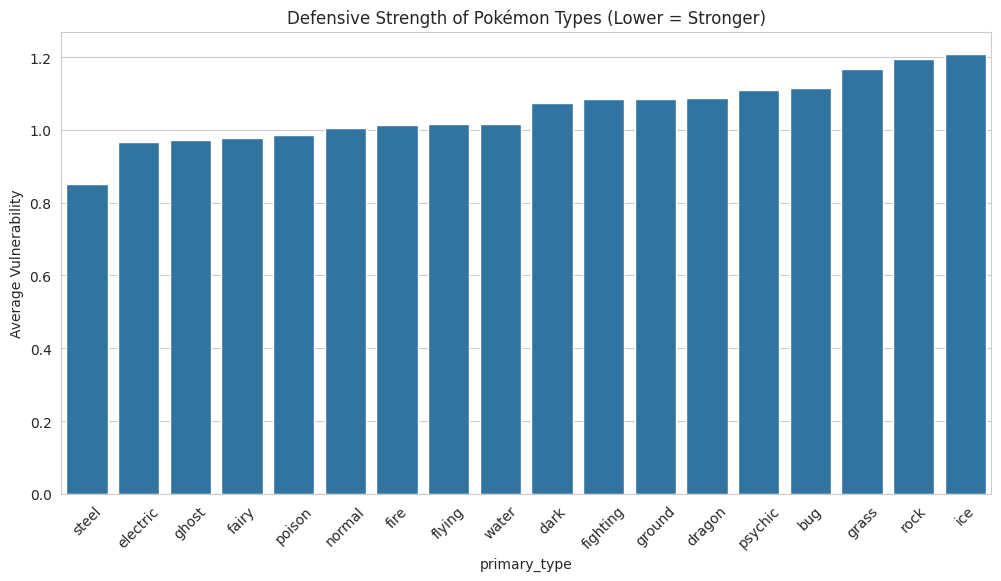

In [84]:
# Which type is the strongest overall? Which is the weakest

against_cols = [col for col in df.columns if col.startswith('against_')]

# Primary type column
types = df['primary_type'].unique()

# Average vulnerability for each primary type
type_strength = df.groupby('primary_type')[against_cols].mean()
type_strength['avg_vulnerability'] = type_strength.mean(axis=1)

# Sort by average vulnerability
type_strength_sorted = type_strength.sort_values('avg_vulnerability')
print(type_strength_sorted[['avg_vulnerability']])


# Plot by vulnerability for each type
plt.figure(figsize=(12,6))
sns.barplot(x=type_strength_sorted.index, y=type_strength_sorted['avg_vulnerability'])
plt.xticks(rotation=45)
plt.ylabel("Average Vulnerability")
plt.title("Defensive Strength of Pokémon Types (Lower = Stronger)")
plt.show()


From the above chart, we can see that the types with lowest average vulnerability (defensive advantage) are Steel, Dragon, and Fairy.

On the other end of the spectrum, we can see that the types with highest vulnerability (defensive disadvantage) are often Rock, Ice, or Grass. This is due to the fact that they are weak / vulnerable to multiple types.

# How many Pokémon are legendary?

In [85]:
# Using value counts, legendary have value of 1 and non-legendary have value of 0
legendary = df['is_legendary'].value_counts()

print(legendary)

is_legendary
0    878
1     20
Name: count, dtype: int64


Starting out, we can see that there are only 20 legendary Pokemon out of a total 898 in our dataset.

Comparing the base stats of legendary vs non-legendary, we can see the following:

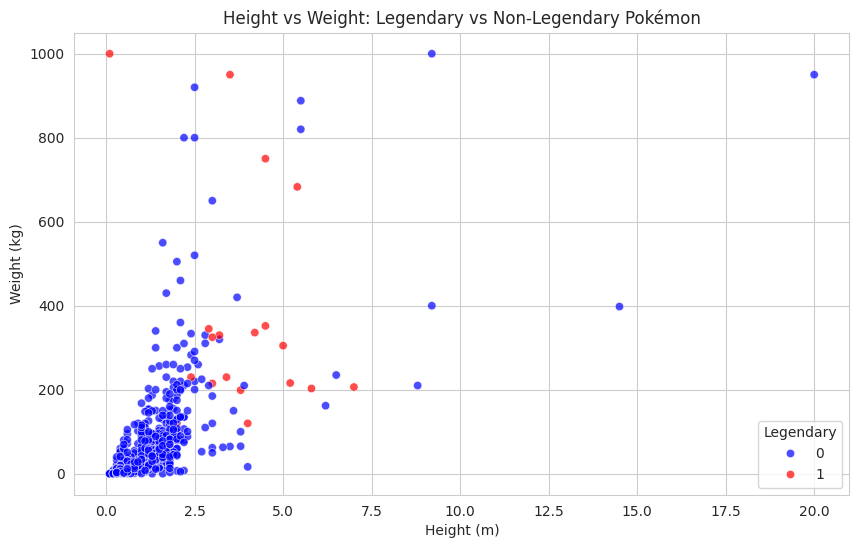

In [86]:

# plot height and weight of both legendary and non-legendary
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='height_m',
    y='weight_kg',
    hue='is_legendary',  # 0 = non-legendary, 1 = legendary
    palette={0:'blue', 1:'red'},
    alpha=0.7
)

plt.title("Height vs Weight: Legendary vs Non-Legendary Pokémon")
plt.xlabel("Height (m)")
plt.ylabel("Weight (kg)")
plt.legend(title="Legendary")
plt.show()

From the above chart, we can see that non-legendary pokemon for the most part are smaller, with most clustering in one area.

Legendary Pokemon are generally larger and heavier, although there are a few outliers.

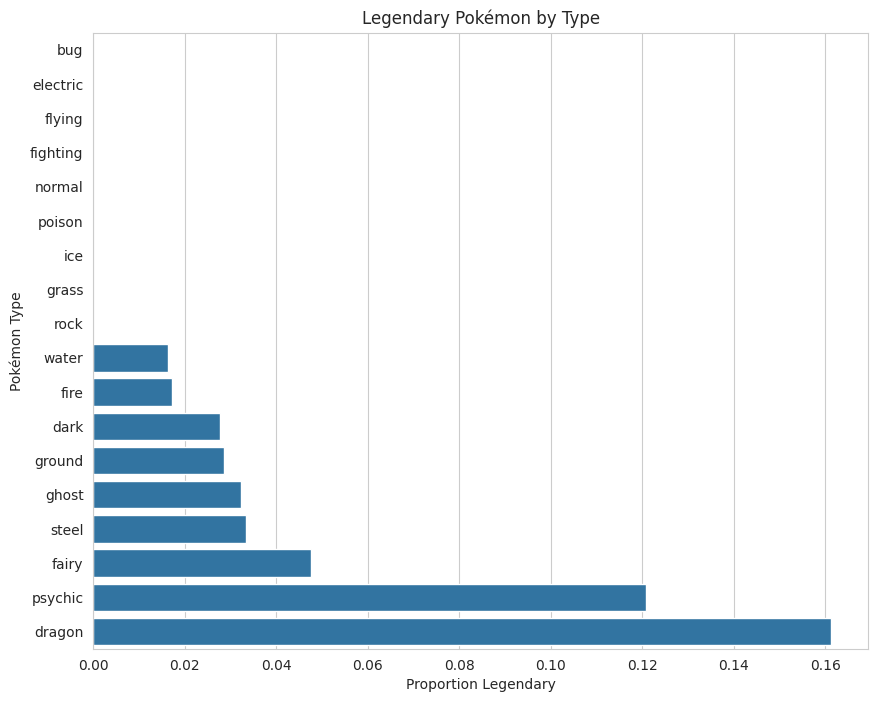

In [87]:
# Group by primary type and calculate proportion of legendary Pokémon
legend_by_type = (
    df.groupby('primary_type')['is_legendary']
      .mean()
      .reset_index()
      .rename(columns={'is_legendary':'prop_legendary'})
      .sort_values('prop_legendary')  # reorder by proportion
)

# Plot to see which types are most common for the Legendary Pokémon
plt.figure(figsize=(10,8))
sns.barplot(
    data=legend_by_type,
    x='prop_legendary',
    y='primary_type'
)
plt.xlabel("Proportion Legendary")
plt.ylabel("Pokémon Type")
plt.title("Legendary Pokémon by Type")
plt.show()

From the above chart, we can see the most common types for Legendary Pokémon are Dragon, Psychic, and Fairy.

<Figure size 1200x800 with 0 Axes>

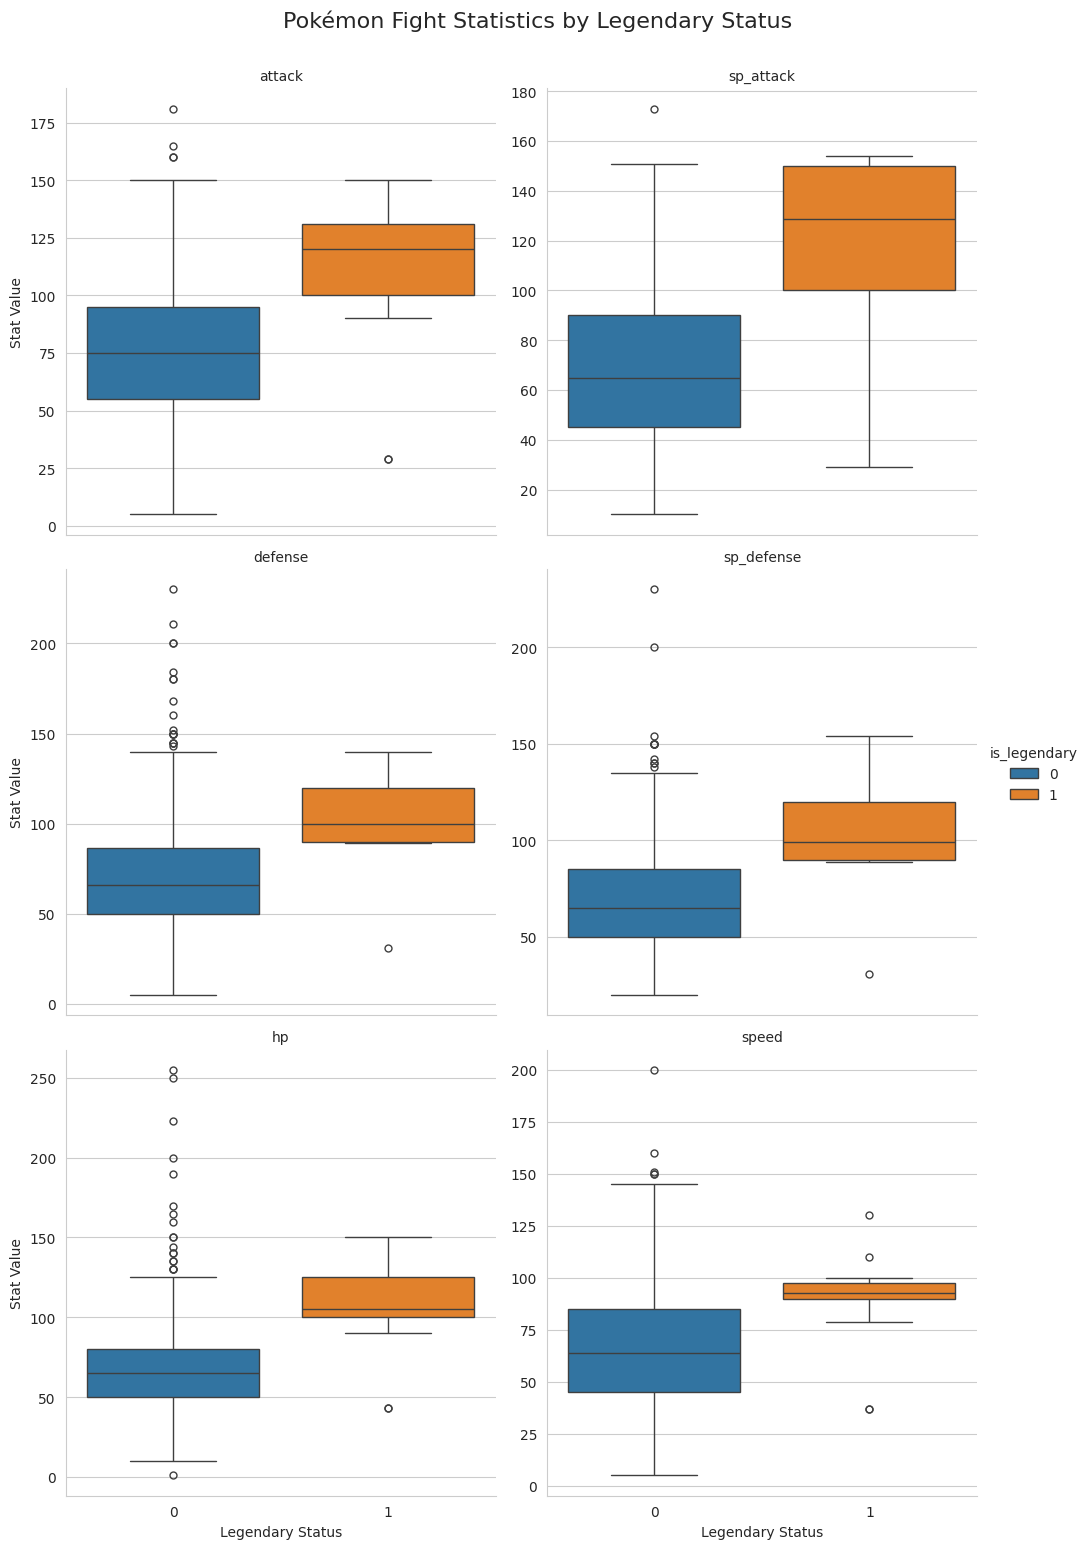

In [88]:
# separate the stat columns
stat_cols = ['attack', 'sp_attack', 'defense', 'sp_defense', 'hp', 'speed']
df[stat_cols + ['is_legendary']] = df[stat_cols + ['is_legendary']].apply(pd.to_numeric, errors='coerce')

# Melt the stats into long format
legend_by_stats = df.melt(
    id_vars='is_legendary',
    value_vars=stat_cols,
    var_name='fight_stat',
    value_name='value'
)

plt.figure(figsize=(12,8))
sns.set_style("whitegrid")

g = sns.catplot(
    data=legend_by_stats,
    x='is_legendary',
    y='value',
    kind='box',
    col='fight_stat',
    hue="is_legendary",
    col_wrap=2,           # 3 columns per row
    sharey=False          # allow y-axis to differ per stat
)

g.set_titles("{col_name}")
g.set_axis_labels("Legendary Status", "Stat Value")
g.fig.suptitle("Pokémon Fight Statistics by Legendary Status", fontsize=16, y=1.03)
plt.show()

After visualizing the affect of each stat's correlation with Legendary status, we are now ready to start training a model to predict based on these features.

Classification Report:

               precision    recall  f1-score   support

Non-Legendary       0.99      1.00      0.99       352
    Legendary       0.80      0.50      0.62         8

     accuracy                           0.99       360
    macro avg       0.89      0.75      0.80       360
 weighted avg       0.98      0.99      0.98       360



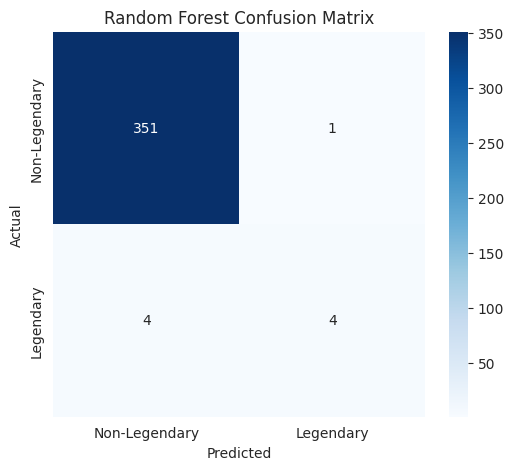

In [89]:
# Prepare train / test split
np.random.seed(1234)
shuffled_indices = np.random.permutation(df.index)
split_idx = int(0.6 * len(df))
train_indices = shuffled_indices[:split_idx]
test_indices = shuffled_indices[split_idx:]

pokedex_train = df.loc[train_indices].reset_index(drop=True)
pokedex_test = df.loc[test_indices].reset_index(drop=True)

# Select features
features = ['attack', 'sp_attack', 'defense', 'sp_defense', 'hp', 'speed']

# One-hot encode the primary type
pokedex_train = pd.get_dummies(pokedex_train, columns=['primary_type'], drop_first=True)
pokedex_test = pd.get_dummies(pokedex_test, columns=['primary_type'], drop_first=True)

# Align columns between train and test
pokedex_test = pokedex_test.reindex(columns=pokedex_train.columns, fill_value=0)

X_train = pokedex_train[features + [col for col in pokedex_train.columns if col.startswith('primary_type_')]]
y_train = pokedex_train['is_legendary']

X_test = pokedex_test[features + [col for col in pokedex_test.columns if col.startswith('primary_type_')]]
y_test = pokedex_test['is_legendary']

# Fit Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=1234)
rf_clf.fit(X_train, y_train)


# Evaluate the model's performance
y_pred = rf_clf.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Non-Legendary','Legendary']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Legendary','Legendary'], yticklabels=['Non-Legendary','Legendary'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


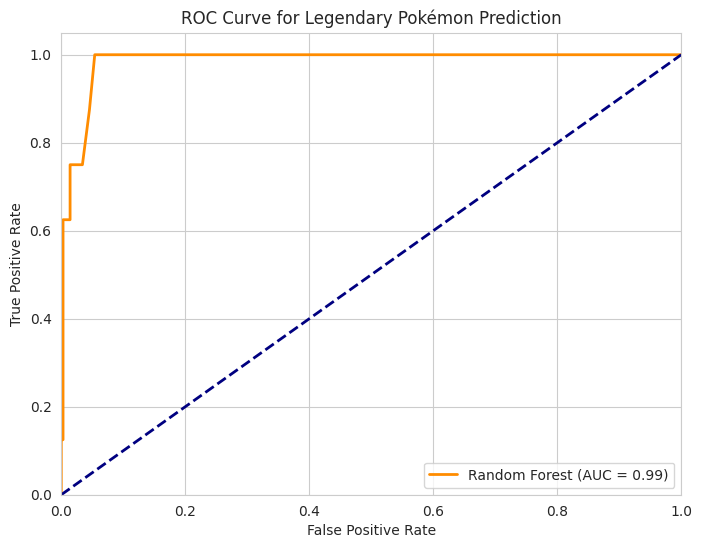

In [90]:

y_prob = rf_clf.predict_proba(X_test)[:, 1]  # probability of being legendary

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Legendary Pokémon Prediction')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Our above model using a Random Forest Classifier is pretty accurate! It has an easier time predicting non-legendary types, but this is likely due to the limited number of legendary types in the dataset.
